In [1]:
# ============================================
# EDA — Retail Sales Dataset
# Analista: tu nombre
# Fecha: junio 2026
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# configuración visual
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [6]:
# ============================================
# 1. CARGA DE DATOS
# ============================================

df = pd.read_csv("/content/train.csv")

print("Dimensiones:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nPrimeras filas:")
df.head()

Dimensiones: (9800, 18)

Columnas: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Primeras filas:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
# ============================================
# 2. EXPLORACIÓN INICIAL
# ============================================

print("Tipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nEstadística general:")
df.describe()

Tipos de datos:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Valores nulos:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Estadística general:


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
# ============================================
# 3. LIMPIEZA DE DATOS
# ============================================

# rellenar Postal Code de Burlington Vermont
df["Postal Code"] = df["Postal Code"].fillna(5401)

# verificar duplicados
print("Duplicados:", df.duplicated().sum())

# convertir fechas a formato datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print("\nDataset limpio. Nulos restantes:", df.isnull().sum().sum())
print("Tipo de Order Date ahora:", df["Order Date"].dtype)

Duplicados: 0

Dataset limpio. Nulos restantes: 0
Tipo de Order Date ahora: datetime64[ns]


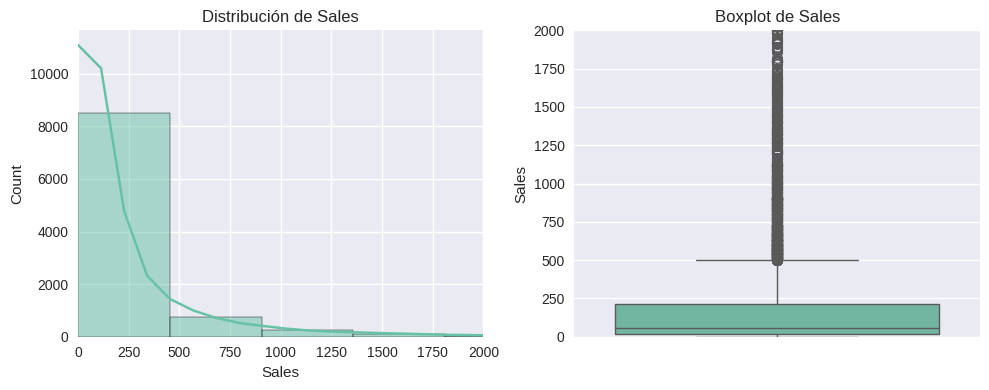

In [9]:
# ============================================
# 4. ANÁLISIS UNIVARIADO
# ============================================

# distribución de Sales
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Distribución de Sales")
plt.xlim(0, 2000)

plt.subplot(1, 2, 2)
sns.boxplot(y=df["Sales"])
plt.title("Boxplot de Sales")
plt.ylim(0, 2000)

plt.tight_layout()
plt.show()

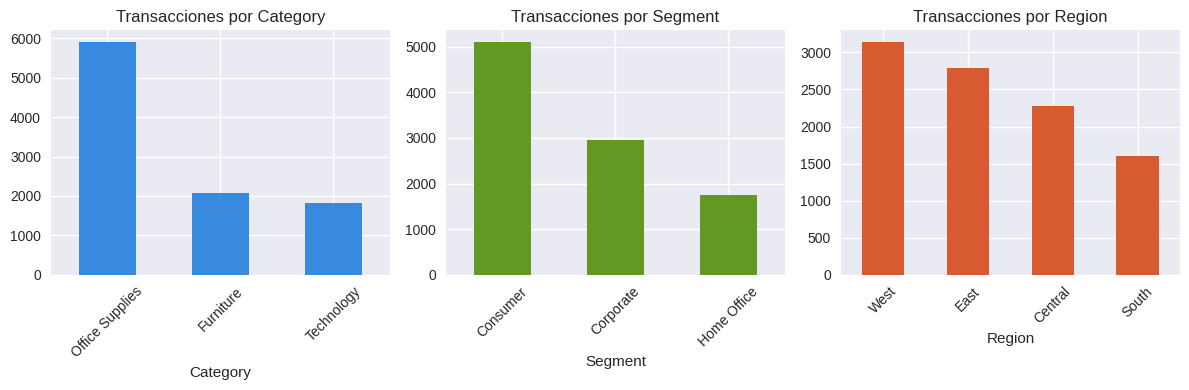

In [10]:
# distribución de categorías
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df["Category"].value_counts().plot(kind="bar", color="#378ADD")
plt.title("Transacciones por Category")
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
df["Segment"].value_counts().plot(kind="bar", color="#639922")
plt.title("Transacciones por Segment")
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
df["Region"].value_counts().plot(kind="bar", color="#D85A30")
plt.title("Transacciones por Region")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

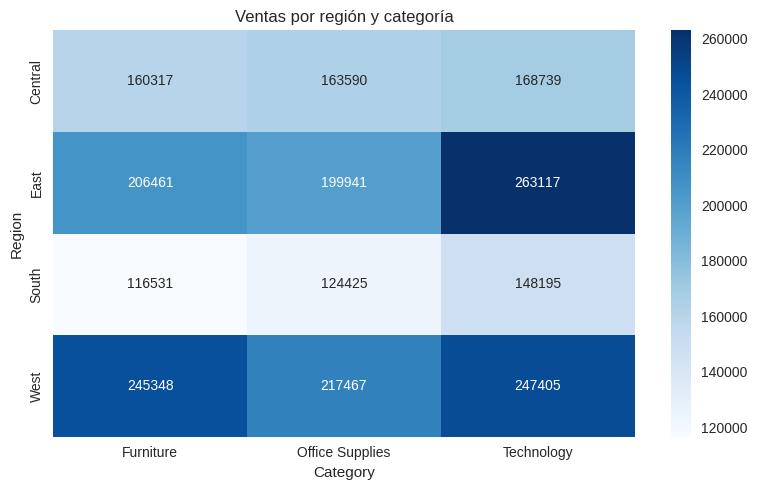

In [11]:
# ============================================
# 5. ANÁLISIS BIVARIADO
# ============================================

# ventas por categoría y región combinadas
pivot = df.pivot_table(values="Sales", index="Region", columns="Category", aggfunc="sum")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Ventas por región y categoría")
plt.tight_layout()
plt.show()

In [12]:
print(pivot)

Category    Furniture  Office Supplies  Technology
Region                                            
Central   160317.4622       163590.243  168739.208
East      206461.3880       199940.811  263116.527
South     116531.4800       124424.771  148195.208
West      245348.2455       217466.509  247404.930


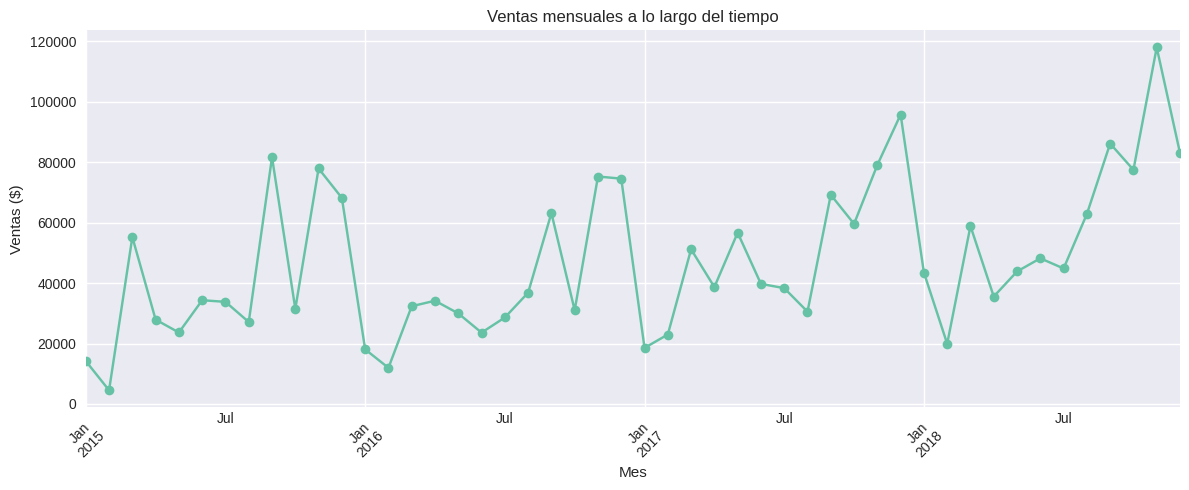

In [13]:
# ventas por mes
df["Mes"] = df["Order Date"].dt.to_period("M")
ventas_mensuales = df.groupby("Mes")["Sales"].sum()

plt.figure(figsize=(12, 5))
ventas_mensuales.plot(kind="line", marker="o")
plt.title("Ventas mensuales a lo largo del tiempo")
plt.xlabel("Mes")
plt.ylabel("Ventas ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# promedio de ventas por mes del año (sin importar el año)
df["Mes_num"] = df["Order Date"].dt.month
ventas_por_mes = df.groupby("Mes_num")["Sales"].sum().round(0)
print(ventas_por_mes)

Mes_num
1      94292.0
2      59371.0
3     197574.0
4     136283.0
5     154087.0
6     145838.0
7     145536.0
8     157316.0
9     300103.0
10    199496.0
11    350162.0
12    321480.0
Name: Sales, dtype: float64


## Conclusiones del EDA

1. **Categoría líder**: Technology genera $827,455 en ventas totales, siendo la categoría más rentable.

2. **Distribución sesgada**: La media de ventas ($230) es 4 veces mayor que la mediana ($54), indicando que pocas transacciones de alto valor inflan el promedio.

3. **Concentración geográfica**: West y East generan el 54% de las ventas totales. South es la región más débil.

4. **Combinación crítica**: Technology + East representa la combinación categoría-región más rentable ($263,116).

5. **Estacionalidad clara**: Noviembre y diciembre concentran los picos de venta del año, mientras febrero es consistentemente el mes más débil.

6. **Calidad de datos**: Se detectaron y corrigieron 11 valores nulos en Postal Code correspondientes a Burlington, Vermont.